In [1]:
import os
import time

import torch
import torch.nn as nn
import torchaudio
import lightning as L

from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint

from melbanks import LogMelFilterBanks

In [2]:
LABEL_MAP = {"no": 0, "yes": 1}

In [3]:
class SpeechCommandsDataModule(L.LightningDataModule):
    def __init__(self, data_dir="./data", batch_size=64, num_workers=0, n_mels=80):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.n_mels = n_mels

        self.mel_fbanks = LogMelFilterBanks(n_mels=self.n_mels)

    def prepare_data(self):
        torchaudio.datasets.SPEECHCOMMANDS(self.data_dir, download=True)

    def setup(self, stage=None):
        self.speech_train = self._filter_binary(
            torchaudio.datasets.SPEECHCOMMANDS(self.data_dir, subset="training")
        )
        self.speech_val = self._filter_binary(
            torchaudio.datasets.SPEECHCOMMANDS(self.data_dir, subset="validation")
        )
        self.speech_test = self._filter_binary(
            torchaudio.datasets.SPEECHCOMMANDS(self.data_dir, subset="testing")
        )

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.speech_train,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn,
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.speech_val,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

    def test_dataloader(self):
        return torch.utils.data.DataLoader(
            self.speech_test,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

    def collate_fn(self, batch):
        waveforms, _, labels, *_ = zip(*batch)
        targets = torch.tensor([LABEL_MAP[l] for l in labels])  # noqa: E741
        waveforms = torch.nn.utils.rnn.pad_sequence(
            [w.squeeze(0) for w in waveforms], batch_first=True
        )
        mel = self.mel_fbanks(waveforms)
        return mel, targets

    def _filter_binary(self, dataset):
        """Keep only 'yes' and 'no' samples by filtering file paths."""
        dataset._walker = [
            path
            for path in dataset._walker
            if os.path.basename(os.path.dirname(path)) in ("yes", "no")
        ]
        return dataset

In [4]:
class SpeechCNN(L.LightningModule):
    def __init__(self, n_mels=80, num_classes=2, lr=1e-3, groups=1):
        super().__init__()
        self.save_hyperparameters()
        self.example_input_array = torch.randn(1, n_mels, 101)
        self.loss_fn = nn.CrossEntropyLoss()

        self.features = nn.Sequential(
            nn.Conv1d(n_mels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

        self._epoch_start_time = None

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return self.classifier(x)

    def training_step(self, batch, batch_idx):
        mel, targets = batch
        logits = self(mel)
        loss = self.loss_fn(logits, targets)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        mel, targets = batch
        logits = self(mel)
        loss = self.loss_fn(logits, targets)
        acc = (logits.argmax(dim=1) == targets).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True, on_epoch=True)

    def on_train_epoch_start(self):
        self._epoch_start_time = time.time()

    def on_train_epoch_end(self):
        elapsed = time.time() - self._epoch_start_time
        self.log("epoch_time_sec", elapsed, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [5]:
MAX_EPOCHS = 30

In [6]:
groups = 1
for n_mels in [20, 40, 80]:
    model = SpeechCNN(n_mels=n_mels, num_classes=2, groups=groups)

    speech_data = SpeechCommandsDataModule(n_mels=n_mels)
    speech_data.prepare_data()
    speech_data.setup(stage="fit")

    logger = TensorBoardLogger(
        "tb_logs",
        name="speech_cnn",
        version=f"nmels{n_mels}_groups{groups}",
    )
    checkpoint_cb = ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        save_last=True,
        filename=f"best-nmels{n_mels}-groups{groups}-" + "{epoch}-{val_acc:.3f}",
    )
    trainer = L.Trainer(
        max_epochs=MAX_EPOCHS,
        logger=logger,
        callbacks=[checkpoint_cb],
        accelerator="auto",
    )

    trainer.fit(model, datamodule=speech_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type             | Params | Mode  | FLOPs  | In sizes     | Out sizes  
----------------------------------------------------------------------------------------------
0 | loss_fn    | CrossEntropyLoss | 0      | train | 0      | ?            | ?          
1 | features   | Sequential       | 34.6 K | train | 2.5 M  | [1, 20, 101] | [1, 128, 1]
2 | classifier | Sequential       | 8.4 K  | train | 16.6 K | [1, 128]     | [1, 2]     
----------------------------------------------------------------------------------------------
43.0 K    Trainable params
0         Non-trainable params
43.0 K    Total params
0.172     Total esti

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

e:\ai_talent_hub\speech-processing\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
e:\ai_talent_hub\speech-processing\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


e:\ai_talent_hub\speech-processing\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 100/100 [00:25<00:00,  3.90it/s, v_num=ups1, train_loss_step=0.00152, val_loss=0.0189, val_acc=0.993, train_loss_epoch=0.00969, epoch_time_sec=25.60] 

...

Epoch 29: 100%|██████████| 100/100 [00:35<00:00,  2.81it/s, v_num=ups1, train_loss_step=0.0354, val_loss=0.0146, val_acc=0.995, train_loss_epoch=0.018, epoch_time_sec=26.50]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type             | Params | Mode  | FLOPs  | In sizes     | Out sizes  
----------------------------------------------------------------------------------------------
0 | loss_fn    | CrossEntropyLoss | 0      | train | 0      | ?            | ?          
1 | features   | Sequential       | 44.2 K | train | 4.4 M  | [1, 80, 101] | [1, 128, 1]
2 | classifier | Sequential       | 8.4 K  | train | 16.6 K | [1, 128]     | [1, 2]     
----------------------------------------------------------------------------------------------
52.6 K    Trainable params
0         Non-trainable params
52.6 K    Total params
0.210     Total esti

Epoch 29: 100%|██████████| 100/100 [00:25<00:00,  3.85it/s, v_num=ups1, train_loss_step=4.67e-6, val_loss=0.0288, val_acc=0.991, train_loss_epoch=0.00656, epoch_time_sec=27.40] 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 100/100 [00:25<00:00,  3.85it/s, v_num=ups1, train_loss_step=4.67e-6, val_loss=0.0288, val_acc=0.991, train_loss_epoch=0.00656, epoch_time_sec=27.40]


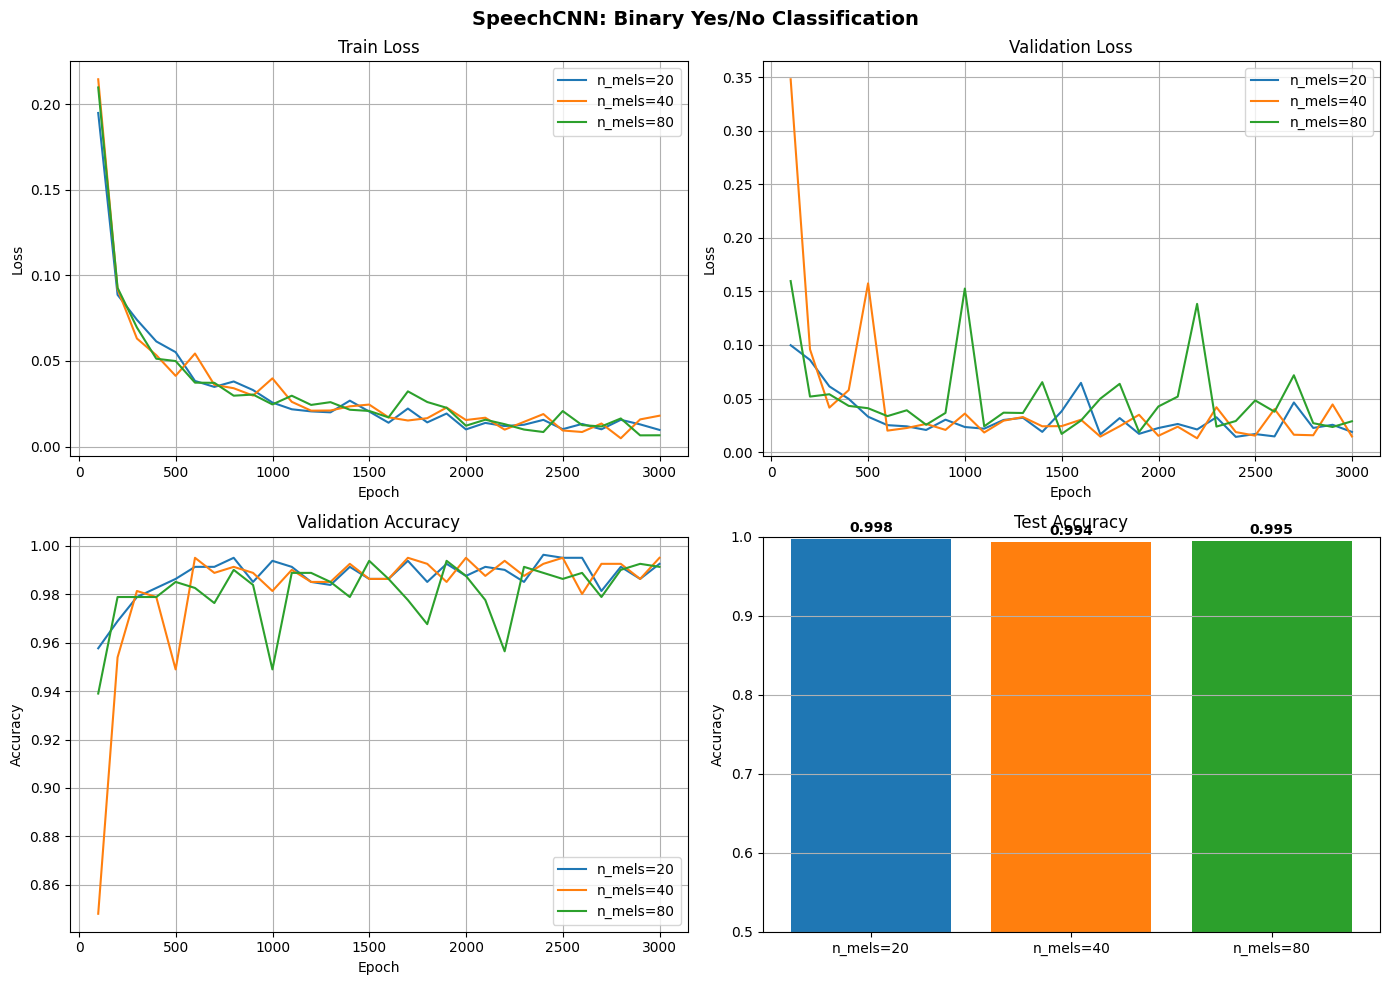

In [10]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

runs = {
    "n_mels=20": "tb_logs/speech_cnn/nmels20_groups1",
    "n_mels=40": "tb_logs/speech_cnn/nmels40_groups1",
    "n_mels=80": "tb_logs/speech_cnn/nmels80_groups1",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Train Loss ---
ax = axes[0, 0]
for label, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("train_loss_epoch")
    ax.plot([e.step for e in events], [e.value for e in events], label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Train Loss")
ax.legend()
ax.grid(True)

# --- Plot 2: Val Loss ---
ax = axes[0, 1]
for label, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("val_loss")
    ax.plot([e.step for e in events], [e.value for e in events], label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Validation Loss")
ax.legend()
ax.grid(True)

# --- Plot 3: Val Accuracy ---
ax = axes[1, 0]
for label, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("val_acc")
    ax.plot([e.step for e in events], [e.value for e in events], label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Validation Accuracy")
ax.legend()
ax.grid(True)

# --- Plot 4: Test Accuracy Bar Plot ---
ax = axes[1, 1]
test_accs = {}
for n_mels in [20, 40, 80]:
    ckpt_dir = f"tb_logs/speech_cnn/nmels{n_mels}_groups1/checkpoints/"
    # Load best checkpoint
    import glob

    ckpt_files = glob.glob(ckpt_dir + "best-*.ckpt")
    if ckpt_files:
        model = SpeechCNN.load_from_checkpoint(ckpt_files[0])
        model.eval()
        model.cuda()

        speech_data_test = SpeechCommandsDataModule(n_mels=n_mels)
        speech_data_test.prepare_data()
        speech_data_test.setup(stage="test")

        correct, total = 0, 0
        with torch.no_grad():
            for mel, targets in speech_data_test.test_dataloader():
                mel, targets = mel.cuda(), targets.cuda()
                preds = model(mel).argmax(dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
        test_accs[f"n_mels={n_mels}"] = correct / total

bars = ax.bar(
    test_accs.keys(), test_accs.values(), color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)
ax.set_ylabel("Accuracy")
ax.set_title("Test Accuracy")
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y")
for bar, acc in zip(bars, test_accs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

fig.suptitle("SpeechCNN: Binary Yes/No Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
n_mels = 80
for groups in [2, 4, 8]:
    model = SpeechCNN(n_mels=n_mels, num_classes=2, groups=groups)
    speech_data = SpeechCommandsDataModule(n_mels=n_mels)
    speech_data.prepare_data()
    speech_data.setup(stage="fit")

    logger = TensorBoardLogger(
        "tb_logs",
        name="speech_cnn",
        version=f"nmels{n_mels}_groups{groups}",
    )
    checkpoint_cb = ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        save_last=True,
        filename=f"best-nmels{n_mels}-groups{groups}-" + "{epoch}-{val_acc:.3f}",
    )
    trainer = L.Trainer(
        max_epochs=MAX_EPOCHS,
        logger=logger,
        callbacks=[checkpoint_cb],
        accelerator="auto",
    )
    trainer.fit(model, datamodule=speech_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type             | Params | Mode  | FLOPs  | In sizes     | Out sizes  
----------------------------------------------------------------------------------------------
0 | loss_fn    | CrossEntropyLoss | 0      | train | 0      | ?            | ?          
1 | features   | Sequential       | 28.8 K | train | 3.5 M  | [1, 80, 101] | [1, 128, 1]
2 | classifier | Sequential       | 8.4 K  | train | 16.6 K | [1, 128]     | [1, 2]     
----------------------------------------------------------------------------------------------
37.2 K    Trainable params
0         Non-trainable params
37.2 K    Total params
0.149     Total esti

Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 142.91it/s]

e:\ai_talent_hub\speech-processing\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
e:\ai_talent_hub\speech-processing\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


e:\ai_talent_hub\speech-processing\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 100/100 [00:24<00:00,  4.10it/s, v_num=ups2, train_loss_step=0.0114, val_loss=0.0335, val_acc=0.989, train_loss_epoch=0.00712, epoch_time_sec=24.60] 

...

Epoch 29: 100%|██████████| 100/100 [00:23<00:00,  4.18it/s, v_num=ups4, train_loss_step=3.17e-5, val_loss=0.0294, val_acc=0.989, train_loss_epoch=0.00902, epoch_time_sec=24.60]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type             | Params | Mode  | FLOPs  | In sizes     | Out sizes  
----------------------------------------------------------------------------------------------
0 | loss_fn    | CrossEntropyLoss | 0      | train | 0      | ?            | ?          
1 | features   | Sequential       | 17.3 K | train | 2.8 M  | [1, 80, 101] | [1, 128, 1]
2 | classifier | Sequential       | 8.4 K  | train | 16.6 K | [1, 128]     | [1, 2]     
----------------------------------------------------------------------------------------------
25.7 K    Trainable params
0         Non-trainable params
25.7 K    Total params
0.103     Total esti

Epoch 29: 100%|██████████| 100/100 [00:25<00:00,  3.93it/s, v_num=ups8, train_loss_step=0.00877, val_loss=0.0209, val_acc=0.994, train_loss_epoch=0.012, epoch_time_sec=25.30]   

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 100/100 [00:25<00:00,  3.93it/s, v_num=ups8, train_loss_step=0.00877, val_loss=0.0209, val_acc=0.994, train_loss_epoch=0.012, epoch_time_sec=25.30]


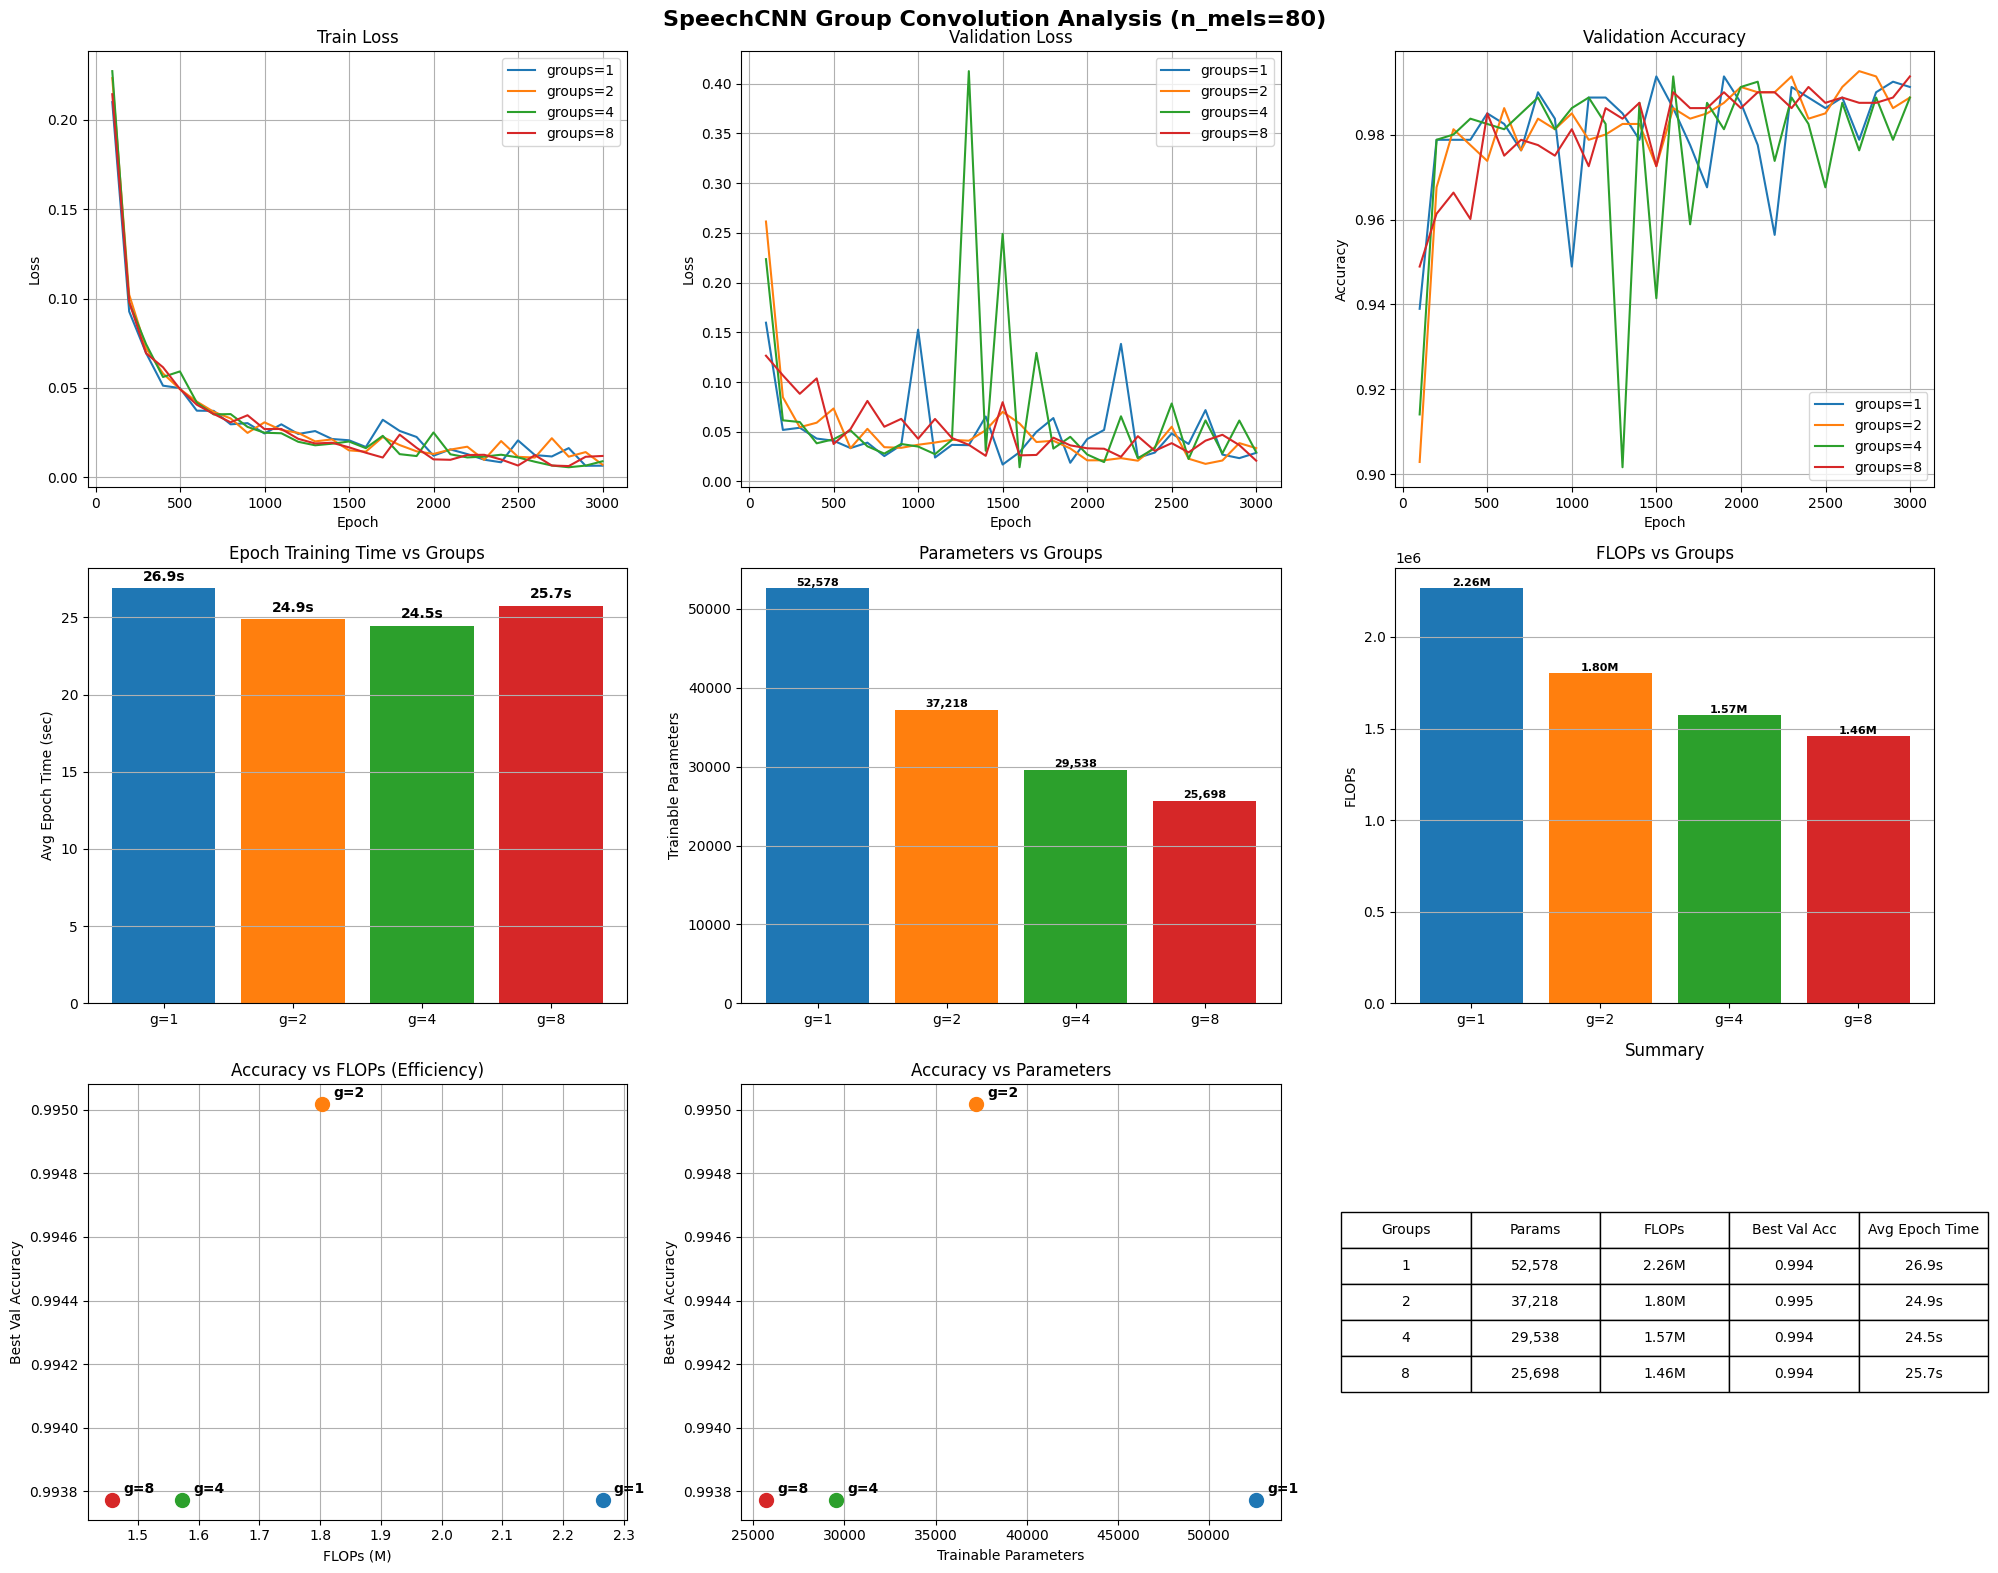

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from thop import profile

n_mels = 80
groups_list = [1, 2, 4, 8]

runs = {g: f"tb_logs/speech_cnn/nmels{n_mels}_groups{g}" for g in groups_list}

fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# --- Row 1, Col 1: Train Loss ---
ax = axes[0, 0]
for g, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("train_loss_epoch")
    ax.plot([e.step for e in events], [e.value for e in events], label=f"groups={g}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Train Loss")
ax.legend()
ax.grid(True)

# --- Row 1, Col 2: Val Loss ---
ax = axes[0, 1]
for g, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("val_loss")
    ax.plot([e.step for e in events], [e.value for e in events], label=f"groups={g}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Validation Loss")
ax.legend()
ax.grid(True)

# --- Row 1, Col 3: Val Accuracy ---
ax = axes[0, 2]
for g, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("val_acc")
    ax.plot([e.step for e in events], [e.value for e in events], label=f"groups={g}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Validation Accuracy")
ax.legend()
ax.grid(True)

# --- Row 2, Col 1: Epoch Training Time vs Groups ---
ax = axes[1, 0]
avg_times = []
for g, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("epoch_time_sec")
    times = [e.value for e in events]
    avg_times.append(np.mean(times))
bars = ax.bar(
    [f"g={g}" for g in groups_list],
    avg_times,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
)
ax.set_ylabel("Avg Epoch Time (sec)")
ax.set_title("Epoch Training Time vs Groups")
ax.grid(axis="y")
for bar, t in zip(bars, avg_times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{t:.1f}s",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# --- Row 2, Col 2: Parameters vs Groups ---
ax = axes[1, 1]
param_counts = []
for g in groups_list:
    model = SpeechCNN(n_mels=n_mels, num_classes=2, groups=g)
    p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    param_counts.append(p)
bars = ax.bar(
    [f"g={g}" for g in groups_list],
    param_counts,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
)
ax.set_ylabel("Trainable Parameters")
ax.set_title("Parameters vs Groups")
ax.grid(axis="y")
for bar, p in zip(bars, param_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{p:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=8,
    )

# --- Row 2, Col 3: FLOPs vs Groups ---
ax = axes[1, 2]
flop_counts = []
for g in groups_list:
    model = SpeechCNN(n_mels=n_mels, num_classes=2, groups=g)
    dummy = torch.randn(1, n_mels, 101)
    flops, _ = profile(model, inputs=(dummy,), verbose=False)
    flop_counts.append(flops)
bars = ax.bar(
    [f"g={g}" for g in groups_list],
    flop_counts,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
)
ax.set_ylabel("FLOPs")
ax.set_title("FLOPs vs Groups")
ax.grid(axis="y")
for bar, f in zip(bars, flop_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"{f / 1e6:.2f}M",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=8,
    )

# --- Row 3, Col 1: Val Accuracy vs FLOPs (efficiency frontier) ---
ax = axes[2, 0]
best_accs = []
for g, logdir in runs.items():
    ea = EventAccumulator(logdir)
    ea.Reload()
    events = ea.Scalars("val_acc")
    best_accs.append(max(e.value for e in events))
for g, flops, acc in zip(groups_list, flop_counts, best_accs):
    ax.scatter(flops / 1e6, acc, s=100, zorder=5)
    ax.annotate(
        f"g={g}",
        (flops / 1e6, acc),
        textcoords="offset points",
        xytext=(8, 5),
        fontweight="bold",
    )
ax.set_xlabel("FLOPs (M)")
ax.set_ylabel("Best Val Accuracy")
ax.set_title("Accuracy vs FLOPs (Efficiency)")
ax.grid(True)

# --- Row 3, Col 2: Val Accuracy vs Parameters ---
ax = axes[2, 1]
for g, params, acc in zip(groups_list, param_counts, best_accs):
    ax.scatter(params, acc, s=100, zorder=5)
    ax.annotate(
        f"g={g}",
        (params, acc),
        textcoords="offset points",
        xytext=(8, 5),
        fontweight="bold",
    )
ax.set_xlabel("Trainable Parameters")
ax.set_ylabel("Best Val Accuracy")
ax.set_title("Accuracy vs Parameters")
ax.grid(True)

# --- Row 3, Col 3: Summary Table ---
ax = axes[2, 2]
ax.axis("off")
table_data = []
for g, params, flops, acc, t in zip(
    groups_list, param_counts, flop_counts, best_accs, avg_times
):
    table_data.append(
        [f"{g}", f"{params:,}", f"{flops / 1e6:.2f}M", f"{acc:.3f}", f"{t:.1f}s"]
    )
table = ax.table(
    cellText=table_data,
    colLabels=["Groups", "Params", "FLOPs", "Best Val Acc", "Avg Epoch Time"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
ax.set_title("Summary", pad=20)

fig.suptitle(
    f"SpeechCNN Group Convolution Analysis (n_mels={n_mels})",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()